# Assignment 03 — Image Classification Using Pretrained CNN Architectures

## Title
**Implementation and Performance Comparison of ResNet50 and GoogLeNet/Inception (InceptionV3) for Image Classification**

## Objective
Implement and compare **ResNet50** and **InceptionV3** using **transfer learning** on **CIFAR-10**.

## Deliverables
- Training code (TensorFlow/Keras)
- Accuracy/Loss curves
- Confusion matrix + classification report
- Comparison: accuracy, loss, training time, model size
- Standalone report exported to Google Drive (`report.html` + `report.md`)

---

## Colab checklist
1. `Runtime → Change runtime type → GPU (T4)`
2. `Runtime → Restart runtime` (recommended before a clean run)
3. `Runtime → Run all`

All outputs are saved to Google Drive folder: `MyDrive/COMP-443/Assignment_03_ResNet_vs_Inception/`.


In [1]:
# =============================
# 1) Setup
# =============================
NOTEBOOK_VERSION = 'assignment03_colab_ready_v4_2026-04-25'
print('Notebook version:', NOTEBOOK_VERSION)

import os
import time
import json
import random
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

print('TensorFlow:', tf.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))

# Avoid TF pre-allocating all VRAM (helps prevent sudden OOMs)
for gpu in tf.config.list_physical_devices('GPU'):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print('Could not set memory growth for', gpu, ':', e)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


Notebook version: assignment03_colab_ready_v4_2026-04-25
TensorFlow: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1.1) Dependencies (Colab)
Colab usually includes these. If imports fail, run the install cell.


In [2]:
# If running in Colab and you get import errors, uncomment:
# !pip -q install -U scikit-learn pandas

from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd


## 1.2) Google Drive (save everything)


In [3]:
# Mount Drive (Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception as e:
    IN_COLAB = False
    print('Not running in Colab (Drive mount skipped):', e)

DRIVE_ROOT = '/content/drive/MyDrive'
PROJECT_DIR = f"{DRIVE_ROOT}/COMP-443/Assignment_03_ResNet_vs_Inception"
LOCAL_DIR = '/content/assignment03_outputs'

OUTPUT_DIR = PROJECT_DIR if IN_COLAB else LOCAL_DIR
os.makedirs(OUTPUT_DIR, exist_ok=True)
print('OUTPUT_DIR =', OUTPUT_DIR)


Mounted at /content/drive
OUTPUT_DIR = /content/drive/MyDrive/COMP-443/Assignment_03_ResNet_vs_Inception


## 1.3) Configuration
Use `FAST_MODE=True` for a quicker first run.


In [4]:
# =============================
# Config
# =============================
FAST_MODE = False           # True: fewer epochs + smaller Inception input

# WARNING: caching *after resize+preprocess* can consume tens of GB and crash mid-epoch.
# Keep this False unless you explicitly want disk caching (set True or 'disk').
CACHE_DATASETS = False      # False | True/'disk' (disk) | 'ram' (RAM)

USE_MIXED_PRECISION = True  # good speedup on T4

RESNET_BATCH_SIZE = 64 if not FAST_MODE else 32
INCEPTION_BATCH_SIZE = 32 if not FAST_MODE else 16

EPOCHS_HEAD = 8 if not FAST_MODE else 4
FINE_TUNE = True
FINE_TUNE_EPOCHS = 7 if not FAST_MODE else 3

RESNET_IMAGE_SIZE = (224, 224)
INCEPTION_IMAGE_SIZE = (299, 299) if not FAST_MODE else (224, 224)

UNFREEZE_LAST_N_RESNET = 40
UNFREEZE_LAST_N_INCEPTION = 60

print('FAST_MODE:', FAST_MODE)
print('CACHE_DATASETS:', CACHE_DATASETS)
print('RESNET_BATCH_SIZE:', RESNET_BATCH_SIZE)
print('INCEPTION_BATCH_SIZE:', INCEPTION_BATCH_SIZE)
print('EPOCHS_HEAD:', EPOCHS_HEAD, 'FINE_TUNE_EPOCHS:', FINE_TUNE_EPOCHS)
print('RESNET_IMAGE_SIZE:', RESNET_IMAGE_SIZE)
print('INCEPTION_IMAGE_SIZE:', INCEPTION_IMAGE_SIZE)


FAST_MODE: False
CACHE_DATASETS: False
RESNET_BATCH_SIZE: 64
INCEPTION_BATCH_SIZE: 32
EPOCHS_HEAD: 8 FINE_TUNE_EPOCHS: 7
RESNET_IMAGE_SIZE: (224, 224)
INCEPTION_IMAGE_SIZE: (299, 299)


In [5]:
# Mixed precision (optional but recommended on T4)
if USE_MIXED_PRECISION:
    try:
        from tensorflow.keras import mixed_precision
        mixed_precision.set_global_policy('mixed_float16')
        print('Mixed precision enabled:', mixed_precision.global_policy())
    except Exception as e:
        print('Mixed precision not enabled:', e)


Mixed precision enabled: <DTypePolicy "mixed_float16">


## 2) Dataset: CIFAR-10


In [6]:
# =============================
# 2) Load CIFAR-10
# =============================
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

y_train = y_train.squeeze().astype('int32')
y_test = y_test.squeeze().astype('int32')

class_names = [
    'airplane','automobile','bird','cat','deer',
    'dog','frog','horse','ship','truck'
]
num_classes = len(class_names)

print('Train:', x_train.shape, y_train.shape)
print('Test :', x_test.shape, y_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
Train: (50000, 32, 32, 3) (50000,)
Test : (10000, 32, 32, 3) (10000,)


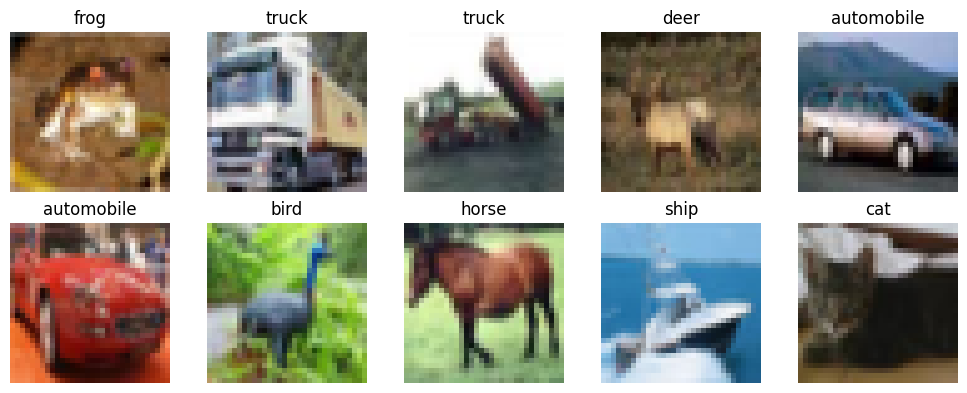

In [7]:
# Visualize samples
plt.figure(figsize=(10,4))
for i in range(10):
    ax = plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()


## 3) Preprocessing + `tf.data`
We resize CIFAR-10 (32×32) to match each backbone input size, then apply the correct `preprocess_input`.


In [8]:
# =============================
# 3) tf.data pipelines
# =============================
AUTOTUNE = tf.data.AUTOTUNE

from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_preprocess

augment = keras.Sequential([
    layers.RandomFlip('horizontal', seed=SEED),
    layers.RandomContrast(0.1, seed=SEED),
], name='augmentation')


def make_splits(x, y, val_fraction=0.1):
    n = x.shape[0]
    n_val = int(n * val_fraction)
    idx = np.arange(n)
    rng = np.random.default_rng(SEED)
    rng.shuffle(idx)
    val_idx = idx[:n_val]
    tr_idx = idx[n_val:]
    return (x[tr_idx], y[tr_idx]), (x[val_idx], y[val_idx])

(x_tr, y_tr), (x_val, y_val) = make_splits(x_train, y_train, val_fraction=0.1)
print('Train split:', x_tr.shape, y_tr.shape)
print('Val split  :', x_val.shape, y_val.shape)


def _apply_cache(ds, name, image_size):
    if not CACHE_DATASETS:
        return ds

    mode = CACHE_DATASETS
    if isinstance(mode, str) and mode.lower() in ('ram', 'memory'):
        return ds.cache()

    # Default to disk cache (safer than RAM). Note: disk usage can still be large.
    cache_dir = '/tmp/assignment03_tfdata_cache'
    if not IN_COLAB:
        cache_dir = os.path.join(OUTPUT_DIR, 'tfdata_cache')
    os.makedirs(cache_dir, exist_ok=True)
    fname = f"{name}_{image_size[0]}x{image_size[1]}.cache"
    return ds.cache(os.path.join(cache_dir, fname))


def make_dataset(x, y, image_size, preprocess_fn, training, batch_size, name):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if training:
        ds = ds.shuffle(10_000, seed=SEED, reshuffle_each_iteration=True)

    def _map(img, label):
        img = tf.cast(img, tf.float32)
        if training:
            img = augment(img)
        img = tf.image.resize(img, image_size, method='bilinear')
        img = preprocess_fn(img)
        return img, tf.one_hot(label, num_classes)

    ds = ds.map(_map, num_parallel_calls=AUTOTUNE)
    ds = _apply_cache(ds, name=name, image_size=image_size)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


train_resnet_ds = make_dataset(x_tr, y_tr, RESNET_IMAGE_SIZE, resnet_preprocess, training=True,  batch_size=RESNET_BATCH_SIZE, name='train_resnet')
val_resnet_ds   = make_dataset(x_val, y_val, RESNET_IMAGE_SIZE, resnet_preprocess, training=False, batch_size=RESNET_BATCH_SIZE, name='val_resnet')

test_resnet_ds  = make_dataset(x_test, y_test, RESNET_IMAGE_SIZE, resnet_preprocess, training=False, batch_size=RESNET_BATCH_SIZE, name='test_resnet')

# sanity
xb, yb = next(iter(train_resnet_ds))
print('Batch:', xb.shape, yb.shape)


Train split: (45000, 32, 32, 3) (45000,)
Val split  : (5000, 32, 32, 3) (5000,)
Batch: (64, 224, 224, 3) (64, 10)


## 4) Training utilities


In [9]:
# =============================
# 4) Utilities
# =============================

class ResourceMonitor(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        # Best-effort diagnostics; safe to ignore failures.
        try:
            if tf.config.list_physical_devices('GPU'):
                info = tf.config.experimental.get_memory_info('GPU:0')
                cur = info.get('current', 0) / (1024**2)
                peak = info.get('peak', 0) / (1024**2)
                print(f"GPU memory (MB) current={cur:.0f} peak={peak:.0f}")
        except Exception:
            pass


def compile_model(model, lr):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )


def fit_with_timing(model, train_ds, val_ds, epochs, callbacks=None, run_name='run'):
    cb = list(callbacks or [])

    # Crash resilience + logs (especially useful on Colab)
    cb.append(keras.callbacks.TerminateOnNaN())
    cb.append(keras.callbacks.BackupAndRestore(backup_dir=os.path.join(OUTPUT_DIR, f'backup_{run_name}')))
    cb.append(keras.callbacks.CSVLogger(os.path.join(OUTPUT_DIR, f'history_{run_name}.csv'), append=True))

    t0 = time.perf_counter()
    hist = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=cb,
        verbose=1,
    )
    t1 = time.perf_counter()
    return hist, (t1 - t0)


def freeze_batchnorm(model_or_layer):
    for l in model_or_layer.layers:
        if isinstance(l, tf.keras.layers.BatchNormalization):
            l.trainable = False


def set_finetune(backbone, unfreeze_last_n):
    backbone.trainable = True

    # Freeze all but last N layers
    for l in backbone.layers[:-unfreeze_last_n]:
        l.trainable = False

    # Keep BN frozen
    freeze_batchnorm(backbone)


def save_model_and_size(model, fname):
    path = os.path.join(OUTPUT_DIR, fname)
    model.save(path, include_optimizer=False)
    size_mb = os.path.getsize(path) / (1024**2)
    return path, size_mb


callbacks = [
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ResourceMonitor(),
]


## 5) Model A — ResNet50 (transfer learning)


In [10]:
# =============================
# 5) ResNet50
# =============================
tf.keras.backend.clear_session()
from tensorflow.keras.applications import ResNet50


def build_resnet50(num_classes):
    inputs = keras.Input(shape=(RESNET_IMAGE_SIZE[0], RESNET_IMAGE_SIZE[1], 3))
    backbone = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(RESNET_IMAGE_SIZE[0], RESNET_IMAGE_SIZE[1], 3),
        pooling='avg',
    )
    backbone.trainable = False

    x = backbone(inputs, training=False)
    x = layers.Dropout(0.3)(x)

    # If mixed precision is enabled, force float32 output for stable softmax/loss
    outputs = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)

    model = keras.Model(inputs, outputs, name='ResNet50_transfer')
    return model, backbone


resnet_model, resnet_backbone = build_resnet50(num_classes)
resnet_model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


Model: "ResNet50_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,608,202 (90.06 MB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [11]:
# Head training
compile_model(resnet_model, lr=1e-3)
resnet_hist_head, resnet_time_head = fit_with_timing(
    resnet_model, train_resnet_ds, val_resnet_ds, EPOCHS_HEAD, callbacks=callbacks, run_name='resnet_head'
)
print(f'ResNet50 head-training time: {resnet_time_head/60:.2f} minutes')


Epoch 1/8
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.7473 - loss: 0.7322GPU memory (MB) current=415 peak=1944
704/704 ━━━━━━━━━━━━━━━━━━━━ 59s 65ms/step - accuracy: 0.8306 - loss: 0.4902 - val_accuracy: 0.8866 - val_loss: 0.3254 - learning_rate: 0.0010
Epoch 2/8
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8799 - loss: 0.3472GPU memory (MB) current=415 peak=1944
704/704 ━━━━━━━━━━━━━━━━━━━━ 34s 49ms/step - accuracy: 0.8811 - loss: 0.3418 - val_accuracy: 0.9092 - val_loss: 0.2755 - learning_rate: 0.0010
Epoch 3/8
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8946 - loss: 0.3118GPU memory (MB) current=415 peak=1944
704/704 ━━━━━━━━━━━━━━━━━━━━ 34s 49ms/step - accuracy: 0.8932 - loss: 0.3136 - val_accuracy: 0.9088 - val_loss: 0.2753 - learning_rate: 0.0010
Epoch 4/8
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8903 - loss: 0.3122GPU memory (MB) current=415 peak=1944
704/704 ━━━━━━━━━━━━━━━━━━━━ 34s 48ms/step - accuracy: 0.8929 - loss: 0.3105 - 

In [12]:
# Fine-tuning
if FINE_TUNE:
    set_finetune(resnet_backbone, UNFREEZE_LAST_N_RESNET)
    compile_model(resnet_model, lr=1e-4)
    resnet_hist_ft, resnet_time_ft = fit_with_timing(
        resnet_model,
        train_resnet_ds,
        val_resnet_ds,
        FINE_TUNE_EPOCHS,
        callbacks=callbacks,
        run_name='resnet_finetune',
    )
    print(f'ResNet50 fine-tuning time: {resnet_time_ft/60:.2f} minutes')
else:
    resnet_hist_ft, resnet_time_ft = None, 0.0


Epoch 1/7
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8911 - loss: 0.3271GPU memory (MB) current=543 peak=1944
704/704 ━━━━━━━━━━━━━━━━━━━━ 65s 69ms/step - accuracy: 0.9073 - loss: 0.2752 - val_accuracy: 0.9238 - val_loss: 0.2352 - learning_rate: 1.0000e-04
Epoch 2/7
702/704 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9459 - loss: 0.1581GPU memory (MB) current=543 peak=1944
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 55ms/step - accuracy: 0.9484 - loss: 0.1500 - val_accuracy: 0.9350 - val_loss: 0.2039 - learning_rate: 1.0000e-04
Epoch 3/7
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9643 - loss: 0.1021GPU memory (MB) current=543 peak=1944
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 56ms/step - accuracy: 0.9648 - loss: 0.1021 - val_accuracy: 0.9390 - val_loss: 0.1857 - learning_rate: 1.0000e-04
Epoch 4/7
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9770 - loss: 0.0703GPU memory (MB) current=543 peak=1944
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 55ms/step - accuracy: 0.9767 - los

## 6) Model B — InceptionV3 (transfer learning)


In [13]:
# =============================
# 6) InceptionV3
# =============================
tf.keras.backend.clear_session()
from tensorflow.keras.applications import InceptionV3


def build_inceptionv3(num_classes):
    inputs = keras.Input(shape=(INCEPTION_IMAGE_SIZE[0], INCEPTION_IMAGE_SIZE[1], 3))
    backbone = InceptionV3(
        weights='imagenet',
        include_top=False,
        input_shape=(INCEPTION_IMAGE_SIZE[0], INCEPTION_IMAGE_SIZE[1], 3),
        pooling='avg',
    )
    backbone.trainable = False

    x = backbone(inputs, training=False)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)
    model = keras.Model(inputs, outputs, name='InceptionV3_transfer')
    return model, backbone


train_inception_ds = make_dataset(x_tr, y_tr, INCEPTION_IMAGE_SIZE, inception_preprocess, training=True,  batch_size=INCEPTION_BATCH_SIZE, name='train_inception')
val_inception_ds   = make_dataset(x_val, y_val, INCEPTION_IMAGE_SIZE, inception_preprocess, training=False, batch_size=INCEPTION_BATCH_SIZE, name='val_inception')

test_inception_ds  = make_dataset(x_test, y_test, INCEPTION_IMAGE_SIZE, inception_preprocess, training=False, batch_size=INCEPTION_BATCH_SIZE, name='test_inception')

inception_model, inception_backbone = build_inceptionv3(num_classes)
inception_model.summary()


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


Model: "InceptionV3_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 2048)           │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,823,274 (83.25 MB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [14]:
# Head training
compile_model(inception_model, lr=1e-3)
inception_hist_head, inception_time_head = fit_with_timing(
    inception_model, train_inception_ds, val_inception_ds, EPOCHS_HEAD, callbacks=callbacks, run_name='inception_head'
)
print(f'InceptionV3 head-training time: {inception_time_head/60:.2f} minutes')


Epoch 1/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7630 - loss: 0.7324GPU memory (MB) current=805 peak=3513
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 69s 39ms/step - accuracy: 0.8194 - loss: 0.5465 - val_accuracy: 0.8612 - val_loss: 0.3943 - learning_rate: 0.0010
Epoch 2/8
1405/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8510 - loss: 0.4309
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
GPU memory (MB) current=805 peak=3513
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 38s 27ms/step - accuracy: 0.8539 - loss: 0.4301 - val_accuracy: 0.8678 - val_loss: 0.3864 - learning_rate: 0.0010
Epoch 3/8
1404/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8700 - loss: 0.3840GPU memory (MB) current=805 peak=3513
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 38s 27ms/step - accuracy: 0.8678 - loss: 0.3891 - val_accuracy: 0.8738 - val_loss: 0.3527 - learning_rate: 5.0000e-04
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.
InceptionV3 head-training 

In [15]:
# Fine-tuning
if FINE_TUNE:
    set_finetune(inception_backbone, UNFREEZE_LAST_N_INCEPTION)
    compile_model(inception_model, lr=1e-4)
    inception_hist_ft, inception_time_ft = fit_with_timing(
        inception_model,
        train_inception_ds,
        val_inception_ds,
        FINE_TUNE_EPOCHS,
        callbacks=callbacks,
        run_name='inception_finetune',
    )
    print(f'InceptionV3 fine-tuning time: {inception_time_ft/60:.2f} minutes')
else:
    inception_hist_ft, inception_time_ft = None, 0.0


Epoch 1/7
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8741 - loss: 0.3750GPU memory (MB) current=891 peak=3513
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 77s 42ms/step - accuracy: 0.8901 - loss: 0.3255 - val_accuracy: 0.9030 - val_loss: 0.2854 - learning_rate: 1.0000e-04
Epoch 2/7
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9376 - loss: 0.1824
Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
GPU memory (MB) current=891 peak=3513
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 44s 31ms/step - accuracy: 0.9384 - loss: 0.1783 - val_accuracy: 0.9150 - val_loss: 0.2511 - learning_rate: 1.0000e-04
Epoch 3/7
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9713 - loss: 0.0826GPU memory (MB) current=891 peak=3513
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 43s 31ms/step - accuracy: 0.9738 - loss: 0.0747 - val_accuracy: 0.9222 - val_loss: 0.2818 - learning_rate: 5.0000e-05
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.
InceptionV3 fine-t

## 7) Evaluation + saving (Drive)
This saves models, metrics JSON, and tables/figures to `OUTPUT_DIR`.


In [16]:
# =============================
# 7) Evaluate + save
# =============================
resnet_test_loss, resnet_test_acc = resnet_model.evaluate(test_resnet_ds, verbose=0)
inc_test_loss, inc_test_acc = inception_model.evaluate(test_inception_ds, verbose=0)

resnet_total_time = float(resnet_time_head + (resnet_time_ft or 0.0))
inception_total_time = float(inception_time_head + (inception_time_ft or 0.0))

resnet_path, resnet_size_mb = save_model_and_size(resnet_model, 'resnet50_cifar10_transfer.keras')
inc_path, inc_size_mb = save_model_and_size(inception_model, 'inceptionv3_cifar10_transfer.keras')

metrics = {
    'resnet50': {
        'test_accuracy': float(resnet_test_acc),
        'test_loss': float(resnet_test_loss),
        'training_time_sec': resnet_total_time,
        'model_size_mb': float(resnet_size_mb),
        'params': int(resnet_model.count_params()),
        'input_size': list(RESNET_IMAGE_SIZE),
        'model_path': resnet_path,
    },
    'inceptionv3': {
        'test_accuracy': float(inc_test_acc),
        'test_loss': float(inc_test_loss),
        'training_time_sec': inception_total_time,
        'model_size_mb': float(inc_size_mb),
        'params': int(inception_model.count_params()),
        'input_size': list(INCEPTION_IMAGE_SIZE),
        'model_path': inc_path,
    },
}

metrics_path = os.path.join(OUTPUT_DIR, 'metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)

print('ResNet50  acc/loss:', float(resnet_test_acc), float(resnet_test_loss))
print('Inception acc/loss:', float(inc_test_acc), float(inc_test_loss))
print('Saved:', metrics_path)


ResNet50  acc/loss: 0.9398000240325928 0.19358372688293457
Inception acc/loss: 0.8988000154495239 0.3014853000640869
Saved: /content/drive/MyDrive/COMP-443/Assignment_03_ResNet_vs_Inception/metrics.json


## 8) Confusion matrices + classification reports


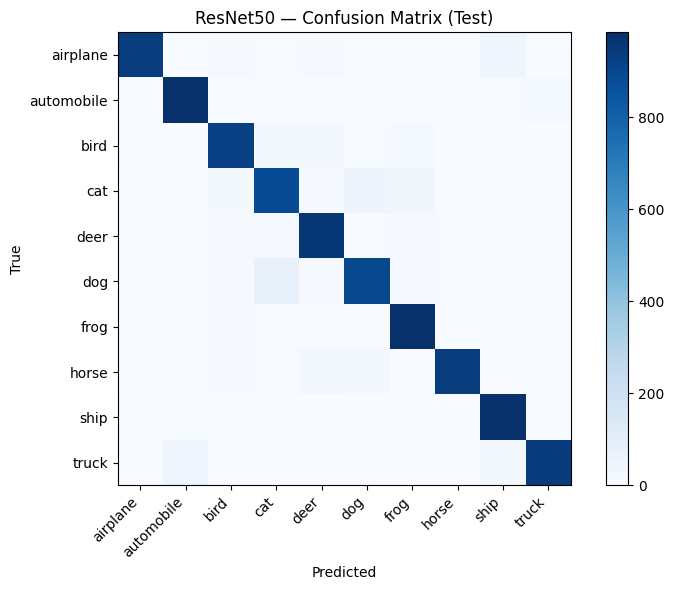

Saved /content/drive/MyDrive/COMP-443/Assignment_03_ResNet_vs_Inception/confusion_matrix_resnet50.png


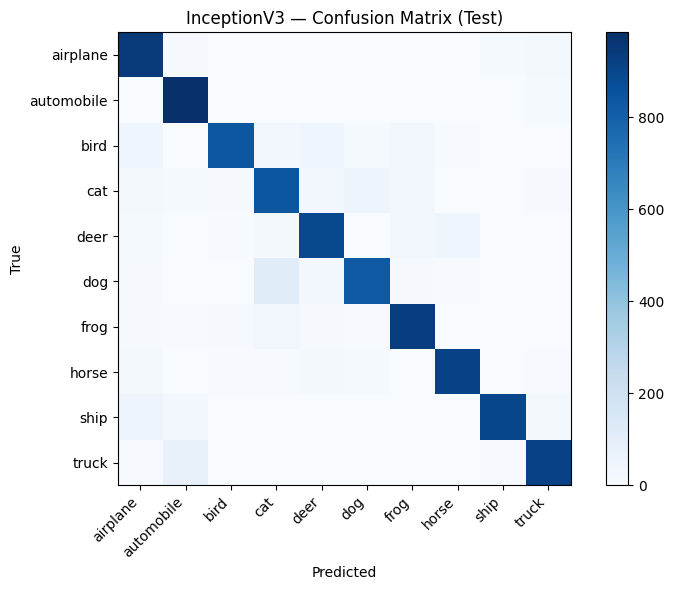

Saved /content/drive/MyDrive/COMP-443/Assignment_03_ResNet_vs_Inception/confusion_matrix_inceptionv3.png
Saved classification reports to OUTPUT_DIR


In [17]:
# =============================
# 8) Confusion matrices
# =============================

def predict_labels(model, ds):
    y_true, y_pred = [], []
    for bx, by in ds:
        probs = model.predict(bx, verbose=0)
        y_pred.append(np.argmax(probs, axis=1))
        y_true.append(np.argmax(by.numpy(), axis=1))
    return np.concatenate(y_true), np.concatenate(y_pred)


def plot_cm(cm, title, filename):
    plt.figure(figsize=(8,6))
    plt.imshow(cm, cmap='Blues')
    plt.title(title)
    plt.colorbar()
    plt.xticks(range(num_classes), class_names, rotation=45, ha='right')
    plt.yticks(range(num_classes), class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(path, dpi=200, bbox_inches='tight')
    plt.show()
    print('Saved', path)


r_true, r_pred = predict_labels(resnet_model, test_resnet_ds)
i_true, i_pred = predict_labels(inception_model, test_inception_ds)

resnet_cm = confusion_matrix(r_true, r_pred)
inc_cm = confusion_matrix(i_true, i_pred)

plot_cm(resnet_cm, 'ResNet50 — Confusion Matrix (Test)', 'confusion_matrix_resnet50.png')
plot_cm(inc_cm, 'InceptionV3 — Confusion Matrix (Test)', 'confusion_matrix_inceptionv3.png')

# Save classification reports
resnet_report = classification_report(r_true, r_pred, target_names=class_names, digits=4)
inc_report = classification_report(i_true, i_pred, target_names=class_names, digits=4)

with open(os.path.join(OUTPUT_DIR, 'classification_report_resnet50.txt'), 'w') as f:
    f.write(resnet_report)
with open(os.path.join(OUTPUT_DIR, 'classification_report_inceptionv3.txt'), 'w') as f:
    f.write(inc_report)

print('Saved classification reports to OUTPUT_DIR')


## 9) Curves: accuracy vs epoch, loss vs epoch


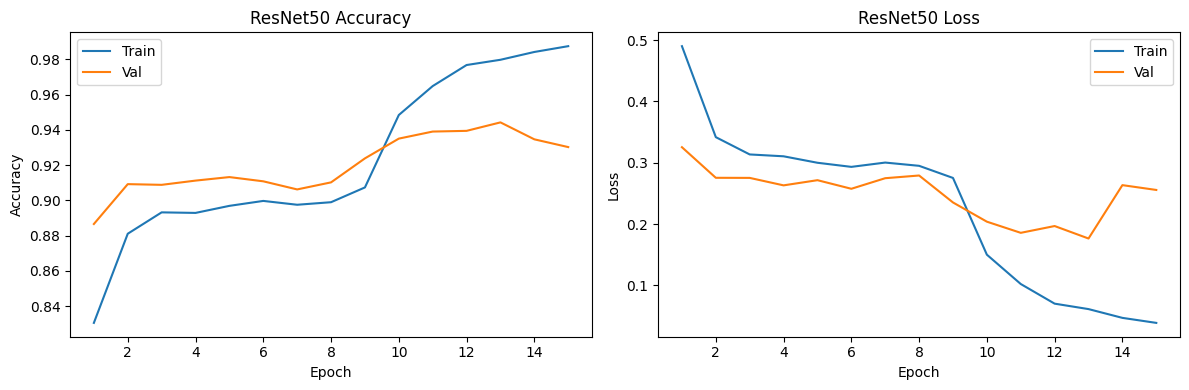

Saved /content/drive/MyDrive/COMP-443/Assignment_03_ResNet_vs_Inception/resnet50_accuracy_loss.png


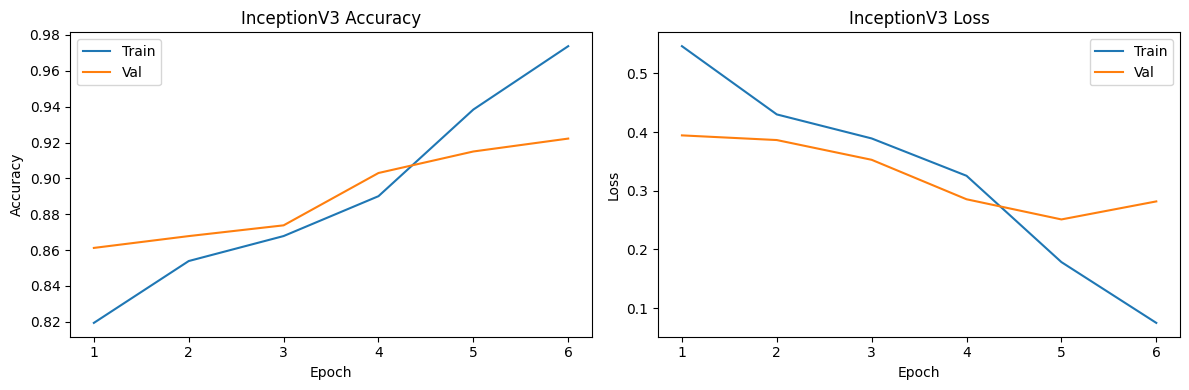

Saved /content/drive/MyDrive/COMP-443/Assignment_03_ResNet_vs_Inception/inceptionv3_accuracy_loss.png


In [18]:
# =============================
# 9) Curves
# =============================

def merge_histories(h1, h2):
    if h2 is None:
        return h1.history
    merged = {k: list(h1.history.get(k, [])) + list(h2.history.get(k, [])) for k in set(h1.history) | set(h2.history)}
    return merged


def plot_curves(hist, title, filename_prefix):
    acc = hist.get('accuracy', [])
    val_acc = hist.get('val_accuracy', [])
    loss = hist.get('loss', [])
    val_loss = hist.get('val_loss', [])
    epochs = range(1, len(acc)+1)

    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(epochs, acc, label='Train')
    plt.plot(epochs, val_acc, label='Val')
    plt.title(f'{title} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs, loss, label='Train')
    plt.plot(epochs, val_loss, label='Val')
    plt.title(f'{title} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    out = os.path.join(OUTPUT_DIR, f'{filename_prefix}_accuracy_loss.png')
    plt.savefig(out, dpi=200, bbox_inches='tight')
    plt.show()
    print('Saved', out)


resnet_hist = merge_histories(resnet_hist_head, resnet_hist_ft)
inc_hist = merge_histories(inception_hist_head, inception_hist_ft)

plot_curves(resnet_hist, 'ResNet50', 'resnet50')
plot_curves(inc_hist, 'InceptionV3', 'inceptionv3')


## 10) Comparison table


In [19]:
# =============================
# 10) Summary table
# =============================
summary = pd.DataFrame([
    {
        'Model': 'ResNet50',
        'Test Accuracy': float(resnet_test_acc),
        'Test Loss': float(resnet_test_loss),
        'Training Time (min)': resnet_total_time/60,
        'Model Size (MB)': float(resnet_size_mb),
        'Params': int(resnet_model.count_params()),
        'Input Size': f'{RESNET_IMAGE_SIZE[0]}x{RESNET_IMAGE_SIZE[1]}',
    },
    {
        'Model': 'InceptionV3',
        'Test Accuracy': float(inc_test_acc),
        'Test Loss': float(inc_test_loss),
        'Training Time (min)': inception_total_time/60,
        'Model Size (MB)': float(inc_size_mb),
        'Params': int(inception_model.count_params()),
        'Input Size': f'{INCEPTION_IMAGE_SIZE[0]}x{INCEPTION_IMAGE_SIZE[1]}',
    },
])

csv_path = os.path.join(OUTPUT_DIR, 'summary_table.csv')
summary.to_csv(csv_path, index=False)
print('Saved', csv_path)
summary


Saved /content/drive/MyDrive/COMP-443/Assignment_03_ResNet_vs_Inception/summary_table.csv


,Model,Test Accuracy,Test Loss,Training Time (min),Model Size (MB),Params,Input Size
0,ResNet50,0.9398,0.193584,9.975128,211.454912,23608202,224x224
1,InceptionV3,0.8988,0.301485,5.218540,164.840771,21823274,299x299


# Short report (3–5 pages worth of content)
Use this text + your produced graphs/tables as the report.

## 1. Introduction
We compare two major pretrained CNN families via transfer learning:
- **ResNet50**: uses residual connections (skip connections) that help optimize deeper networks.
- **InceptionV3**: uses multi-branch Inception modules to capture multi-scale features efficiently.

## 2. Dataset & preprocessing
We use **CIFAR-10** (10 classes, 32×32 images). Since ImageNet-pretrained models expect larger inputs, we resize:
- ResNet50 → `RESNET_IMAGE_SIZE`
- InceptionV3 → `INCEPTION_IMAGE_SIZE`

We apply lightweight augmentation (flip/contrast) and the correct model-specific preprocessing (`preprocess_input`).

## 3. Transfer learning procedure
1) Freeze backbone and train a new classifier head.
2) Fine-tune: unfreeze only the last N layers with a lower learning rate. BatchNorm layers remain frozen for stability.

## 4. Results
Use `summary_table.csv`, confusion matrices, and classification reports saved to Drive.

## 5. Discussion (why one performed better)
Typical reasons (connect these to your outputs):
- **Architecture**: residual learning vs multi-branch inception features.
- **Input resizing**: CIFAR-10 is low-res; resizing can blur details. Larger resize (e.g., 299×299) increases compute.
- **Compute/time tradeoff**: InceptionV3 often takes longer per epoch.
- **Class confusion**: CIFAR-10 often confuses similar classes (cat vs dog, deer vs horse). Use confusion matrices to justify.

## 6. Conclusion
Conclude based on final test accuracy, training time, and model size (deployment practicality).


## 11) Export standalone report (HTML + Markdown)


In [20]:
# =============================
# 11) Export report.html + report.md
# =============================
import datetime

def img_tag(fname, caption):
    full = os.path.join(OUTPUT_DIR, fname)
    if os.path.exists(full):
        return f'<figure><img src="{fname}" style="max-width:100%;border:1px solid #ddd"/><figcaption>{caption}</figcaption></figure>'
    return f'<p><b>Missing:</b> {fname}</p>'

# Build HTML
stamp = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
summary_html = summary.to_html(index=False)

html = f'''<!doctype html>
<html>
<head>
  <meta charset="utf-8">
  <meta name="viewport" content="width=device-width, initial-scale=1">
  <title>Assignment 03 Report — ResNet50 vs InceptionV3</title>
  <style>
    body {{ font-family: Arial, sans-serif; margin: 24px; line-height: 1.45; }}
    h1,h2,h3 {{ margin-bottom: 8px; }}
    .meta {{ color: #444; margin-bottom: 18px; }}
    table {{ border-collapse: collapse; width: 100%; }}
    th, td {{ border: 1px solid #ddd; padding: 8px; text-align: left; }}
    th {{ background: #f5f5f5; }}
    figure {{ margin: 16px 0; }}
    figcaption {{ color: #555; font-size: 0.95em; margin-top: 6px; }}
    code {{ background:#f6f6f6; padding:2px 4px; }}
  </style>
</head>
<body>
  <h1>Assignment 03 Report</h1>
  <div class="meta">
    Generated: {stamp}<br>
    Dataset: CIFAR-10<br>
    Models: ResNet50, InceptionV3<br>
    Outputs folder: <code>{OUTPUT_DIR}</code>
  </div>

  <h2>Summary Table</h2>
  {summary_html}

  <h2>Training Curves</h2>
  {img_tag('resnet50_accuracy_loss.png', 'ResNet50 accuracy/loss vs epoch')}
  {img_tag('inceptionv3_accuracy_loss.png', 'InceptionV3 accuracy/loss vs epoch')}

  <h2>Confusion Matrices</h2>
  {img_tag('confusion_matrix_resnet50.png', 'ResNet50 confusion matrix (test)')}
  {img_tag('confusion_matrix_inceptionv3.png', 'InceptionV3 confusion matrix (test)')}

  <h2>Files</h2>
  <ul>
    <li><code>summary_table.csv</code>, <code>metrics.json</code></li>
    <li><code>classification_report_resnet50.txt</code>, <code>classification_report_inceptionv3.txt</code></li>
    <li><code>resnet50_cifar10_transfer.keras</code>, <code>inceptionv3_cifar10_transfer.keras</code></li>
  </ul>

  <h2>Discussion (template)</h2>
  <p>
    Use the summary table and confusion matrices to explain which model performed better.
    Comment on accuracy vs training time vs model size and typical CIFAR-10 confusions.
  </p>
</body>
</html>
'''

html_path = os.path.join(OUTPUT_DIR, 'report.html')
with open(html_path, 'w', encoding='utf-8') as f:
    f.write(html)
print('Saved', html_path)

md_path = os.path.join(OUTPUT_DIR, 'report.md')
md_text = f'''# Assignment 03 Report — ResNet50 vs InceptionV3 (CIFAR-10)

Generated: {stamp}

## Outputs folder
`{OUTPUT_DIR}`

## Key artifacts
- `summary_table.csv`
- `metrics.json`
- `resnet50_accuracy_loss.png`, `inceptionv3_accuracy_loss.png`
- `confusion_matrix_resnet50.png`, `confusion_matrix_inceptionv3.png`
- `classification_report_resnet50.txt`, `classification_report_inceptionv3.txt`
- `resnet50_cifar10_transfer.keras`, `inceptionv3_cifar10_transfer.keras`

## Summary
(See `summary_table.csv` or `report.html`.)

## Observations (write based on your outputs)
- Accuracy vs compute tradeoffs
- Why one model converged better
- Which classes are confused and why
'''

with open(md_path, 'w', encoding='utf-8') as f:
    f.write(md_text)
print('Saved', md_path)


Saved /content/drive/MyDrive/COMP-443/Assignment_03_ResNet_vs_Inception/report.html
Saved /content/drive/MyDrive/COMP-443/Assignment_03_ResNet_vs_Inception/report.md


## 12) Optional: Zip outputs


In [21]:
import zipfile
zip_path = os.path.join(OUTPUT_DIR, 'assignment03_outputs.zip')
with zipfile.ZipFile(zip_path, 'w', compression=zipfile.ZIP_DEFLATED) as z:
    for root, _, files in os.walk(OUTPUT_DIR):
        for fn in files:
            if fn.endswith('.zip'):
                continue
            full = os.path.join(root, fn)
            rel = os.path.relpath(full, OUTPUT_DIR)
            z.write(full, arcname=rel)
print('Saved', zip_path)


Saved /content/drive/MyDrive/COMP-443/Assignment_03_ResNet_vs_Inception/assignment03_outputs.zip
